In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: userhappyha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/apples-or-tomatoes-image-classification


100%|██████████| 2.33M/2.33M [00:01<00:00, 1.97MB/s]

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D , Flatten, Dense
from keras.layers import MaxPool2D , Flatten , Dense , Conv2D

In [4]:
train_dataset = keras.utils.image_dataset_from_directory(
    directory="/content/apples-or-tomatoes-image-classification/train",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256),
    shuffle=True,
)

validation_dataset = keras.utils.image_dataset_from_directory(
    directory="/content/apples-or-tomatoes-image-classification/test",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256),
    shuffle=True,
)

Found 294 files belonging to 2 classes.
Found 97 files belonging to 2 classes.


In [5]:
def normalize(image, label):
    image = image / 255.0
    return image, label

train_dataset = train_dataset.map(normalize)
validation_dataset = validation_dataset.map(normalize)

In [6]:
IMAGE_SIZE = [224, 224]

In [78]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , BatchNormalization

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
# model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
# model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(3,3),activation='relu',padding='same'))
# model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))    # Drop 50% neurons during training

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 55, 55, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │    11,944,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,045,633 (45.95 MB)

 Trainable params: 12,045,633 (45.95 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [80]:

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255)

In [81]:
training_set = train_datagen.flow_from_directory("/content/apples-or-tomatoes-image-classification/train",
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')


Found 294 images belonging to 2 classes.


In [82]:

test_set = test_datagen.flow_from_directory("/content/apples-or-tomatoes-image-classification/test",
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'binary')

Found 97 images belonging to 2 classes.


In [83]:
model.compile(optimizer="Adam",loss='binary_crossentropy',metrics=['accuracy'])

In [84]:
# callbacks = [
#     keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
#                                    restore_best_weights=True,verbose=True),
#     # keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
#     #                                    patience=3, min_lr=1e-6)
# ]


history = model.fit(
  training_set,
  validation_data=test_set,
  epochs=25,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 652ms/step - accuracy: 0.5136 - loss: 0.8730 - val_accuracy: 0.6082 - val_loss: 0.6738
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.6429 - loss: 0.6558 - val_accuracy: 0.6598 - val_loss: 0.6328
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 330ms/step - accuracy: 0.6871 - loss: 0.6167 - val_accuracy: 0.6392 - val_loss: 0.6106
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.7041 - loss: 0.5887 - val_accuracy: 0.6804 - val_loss: 0.6049
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 442ms/step - accuracy: 0.6429 - loss: 0.6410 - val_accuracy: 0.6495 - val_loss: 0.6116
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.7313 - loss: 0.5904 - val_accuracy: 0.6392 - val_loss: 0.5992
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.7381 - loss: 0.5503 - val_accuracy: 0.7320 - val_loss: 0.5496
Epoch 8/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 405ms/step - accuracy: 0.6871 - loss: 0.5563 - val_accuracy: 0

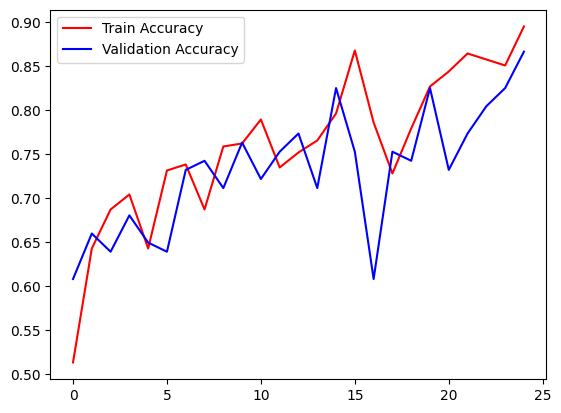

In [85]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='Train Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')

plt.legend()
plt.show()

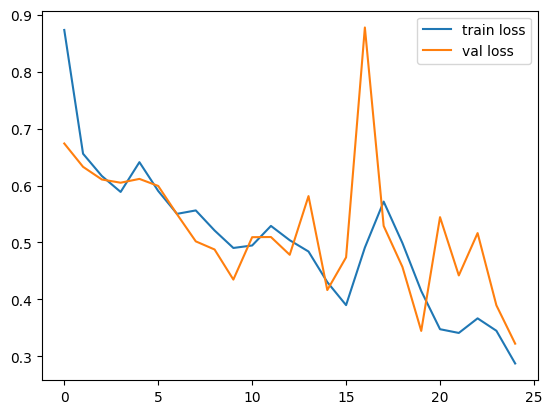

In [98]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [90]:
model.save('model.h5')

In [89]:
# Pehle class names le lo
class_names = ['apples', 'tomatoes']  # ya hardcode karo

import numpy as np
import matplotlib.pyplot as plt

# Images aur labels collect karo
test_images = []
test_labels = []

for images, labels in validation_dataset:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

test_images = np.concatenate(test_images, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

# Predictions
predictions = model.predict(validation_dataset)

# Plot
plt.figure(figsize=(16, 12))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(test_images[i])

    actual = class_names[int(test_labels[i])]

    pred_prob = predictions[i][0]
    predicted_idx = 1 if pred_prob > 0.5 else 0
    predicted = class_names[predicted_idx]
    confidence = pred_prob if predicted_idx == 1 else 1 - pred_prob

    color = 'green' if actual == predicted else 'red'
    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.0%})",
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

AttributeError: 'History' object has no attribute 'predict'

In [91]:
from tensorflow.keras.models import load_model

model = load_model('model.h5')

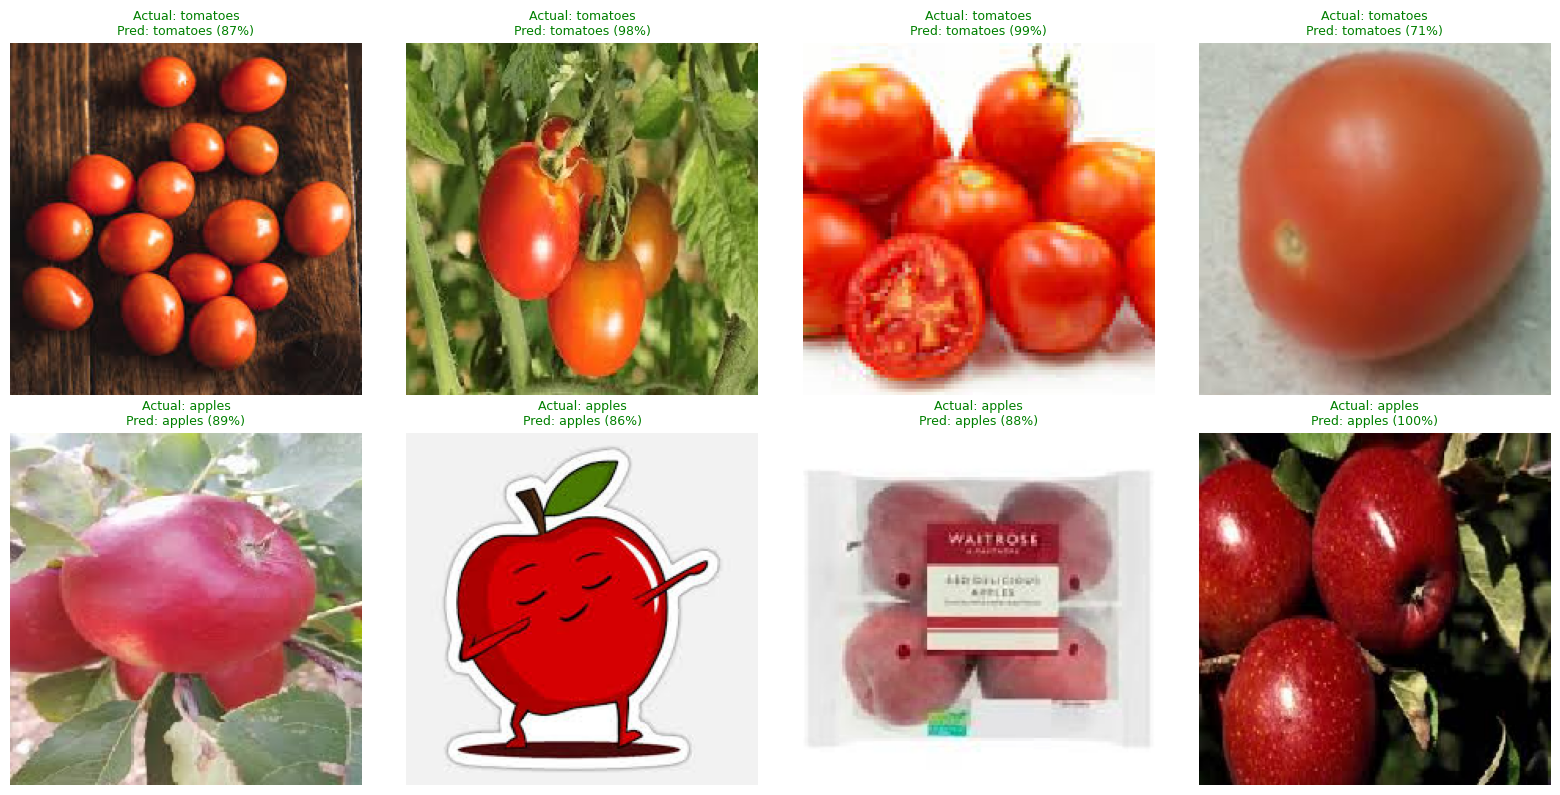

In [97]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = ['apples', 'tomatoes']

image_paths = [
    ('/content/apples-or-tomatoes-image-classification/test/tomatoes/img_p1_105.jpeg', 'tomatoes'),
    ('/content/apples-or-tomatoes-image-classification/test/tomatoes/img_p1_107.jpeg', 'tomatoes'),
    ('/content/apples-or-tomatoes-image-classification/test/tomatoes/img_p1_15.jpeg', 'tomatoes'),
    ('/content/apples-or-tomatoes-image-classification/test/tomatoes/img_p1_43.jpeg', 'tomatoes'),
    ('/content/apples-or-tomatoes-image-classification/test/apples/img_p1_111.jpeg', 'apples'),
    ('/content/apples-or-tomatoes-image-classification/test/apples/img_p1_127.jpeg', 'apples'),
    ('/content/apples-or-tomatoes-image-classification/test/apples/img_p1_30.jpeg', 'apples'),
    ('/content/apples-or-tomatoes-image-classification/test/apples/img_p1_68.jpeg', 'apples'),
]

plt.figure(figsize=(16, 8))

for i, (img_path, actual) in enumerate(image_paths):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    pred_prob = prediction[0][0]
    predicted_idx = 1 if pred_prob > 0.5 else 0
    predicted = class_names[predicted_idx]
    confidence = pred_prob if predicted_idx == 1 else 1 - pred_prob

    color = 'green' if actual == predicted else 'red'

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Actual: {actual}\nPred: {predicted} ({confidence:.0%})", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()